In [1]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.datasets import Planetoid

/home/njz/study_graph/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## データ用意

In [2]:
dataset = Planetoid(root="./dataset", name="Cora", split="full")

In [3]:
from torch_geometric.transforms import RandomNodeSplit

node_splitter = RandomNodeSplit(
    split="train_rest",
    num_splits=1,
    num_val=0.0,
    num_test=0.4,
    key="y",
)
splitted_data = node_splitter(dataset._data)

In [4]:
print(splitted_data.node_attrs())
print(splitted_data.train_mask)
print(splitted_data.test_mask)

['test_mask', 'y', 'x', 'val_mask', 'train_mask']
tensor([False, False, False,  ...,  True,  True,  True])
tensor([ True,  True,  True,  ..., False, False, False])


## 分類問題

In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

## モデルとOptimizerの用意

In [6]:
class GCN(torch.nn.Module):
    def __init__(
        self,
        num_node_features: int,
        projection_dim: int,
        num_classes: int,
    ) -> None:
        super().__init__()
        self.conv1 = GCNConv(num_node_features, projection_dim)
        self.conv2 = GCNConv(projection_dim, num_classes)
        
    def forward(self, data: Data) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)
        
        return F.log_softmax(x, dim=1)

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gcn_model = GCN(
    num_node_features=dataset.num_node_features,
    projection_dim=64,
    num_classes=dataset.num_classes,
).to(device)

gcn_optimizer = torch.optim.Adam(gcn_model.parameters(), lr=0.01)

### 学習

In [13]:
from tqdm import tqdm

def train_gcn() -> float:
    gcn_model.train()
    total_loss = 0.0
    gcn_optimizer.zero_grad()
    out = gcn_model(splitted_data.to(device))
    
    loss = F.cross_entropy(out[splitted_data.train_mask], splitted_data.y[splitted_data.train_mask])
    loss.backward()
    gcn_optimizer.step()
    
    return loss.item()

In [14]:
for epoch in range(1, 201):
    loss = train_gcn()
    print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}")

Epoch: 001, Loss: 0.9455
Epoch: 002, Loss: 1.0450
Epoch: 003, Loss: 0.9218
Epoch: 004, Loss: 1.1016
Epoch: 005, Loss: 0.9364
Epoch: 006, Loss: 1.1037
Epoch: 007, Loss: 0.9557
Epoch: 008, Loss: 0.9570
Epoch: 009, Loss: 0.8525
Epoch: 010, Loss: 0.9204
Epoch: 011, Loss: 1.0277
Epoch: 012, Loss: 0.9877
Epoch: 013, Loss: 1.0635
Epoch: 014, Loss: 0.9847
Epoch: 015, Loss: 1.0042
Epoch: 016, Loss: 1.1521
Epoch: 017, Loss: 1.0638
Epoch: 018, Loss: 1.0446
Epoch: 019, Loss: 0.9716
Epoch: 020, Loss: 0.9511
Epoch: 021, Loss: 1.0621
Epoch: 022, Loss: 1.0301
Epoch: 023, Loss: 1.0075
Epoch: 024, Loss: 0.9436
Epoch: 025, Loss: 0.9388
Epoch: 026, Loss: 0.9877
Epoch: 027, Loss: 1.0407
Epoch: 028, Loss: 1.0899
Epoch: 029, Loss: 1.0259
Epoch: 030, Loss: 1.0131
Epoch: 031, Loss: 1.0532
Epoch: 032, Loss: 0.9807
Epoch: 033, Loss: 1.0268
Epoch: 034, Loss: 0.9202
Epoch: 035, Loss: 1.0417
Epoch: 036, Loss: 0.9385
Epoch: 037, Loss: 1.0130
Epoch: 038, Loss: 1.0089
Epoch: 039, Loss: 0.9916
Epoch: 040, Loss: 0.9408


### 評価

In [15]:
from sklearn.metrics import classification_report

y_true = splitted_data.y[splitted_data.test_mask].cpu().numpy()

# 評価データに対する推論
with torch.no_grad():
    gcn_model.eval()
    out = gcn_model(splitted_data)
y_pred = out.argmax(dim=1)[splitted_data.test_mask].cpu().numpy()

In [16]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.51      0.64       146
           1       0.84      0.84      0.84        95
           2       0.90      0.99      0.94       172
           3       0.82      0.89      0.85       315
           4       0.89      0.90      0.89       173
           5       0.71      0.86      0.78       113
           6       0.84      0.77      0.80        69

    accuracy                           0.84      1083
   macro avg       0.84      0.82      0.82      1083
weighted avg       0.84      0.84      0.83      1083



### フィルタの差し替え（GraphSAGE）

In [18]:
from torch_geometric.nn import SAGEConv

class GraphSAGE(torch.nn.Module):
    def __init__(
        self,
        num_node_features: int,
        projection_dim: int,
        num_classes: int,
    ) -> None:
        super().__init__()
        self.conv1 = SAGEConv(num_node_features, projection_dim)
        self.conv2 = SAGEConv(projection_dim, num_classes)

    def forward(self, data: Data) -> torch.Tensor:
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, edge_index)

        return F.log_softmax(x, dim=1)


In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
graphsage_model = GraphSAGE(
    num_node_features=dataset.num_node_features,
    projection_dim=64,
    num_classes=dataset.num_classes,
).to(device)

graphsage_optimizer = torch.optim.Adam(graphsage_model.parameters(), lr=0.01)


In [20]:
def train_graphsage() -> float:
    gcn_model.train()
    total_loss = 0.0
    graphsage_optimizer.zero_grad()
    out = graphsage_model(splitted_data.to(device))

    loss = F.cross_entropy(
        out[splitted_data.train_mask], splitted_data.y[splitted_data.train_mask]
    )
    loss.backward()
    graphsage_optimizer.step()

    return loss.item()


for epoch in range(1, 201):
    loss = train_graphsage()
    print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}")


Epoch: 001, Loss: 1.9253
Epoch: 002, Loss: 1.6283
Epoch: 003, Loss: 1.3336
Epoch: 004, Loss: 1.0446
Epoch: 005, Loss: 0.8082
Epoch: 006, Loss: 0.6237
Epoch: 007, Loss: 0.4707
Epoch: 008, Loss: 0.3774
Epoch: 009, Loss: 0.2843
Epoch: 010, Loss: 0.2403
Epoch: 011, Loss: 0.1978
Epoch: 012, Loss: 0.1730
Epoch: 013, Loss: 0.1393
Epoch: 014, Loss: 0.1263
Epoch: 015, Loss: 0.1117
Epoch: 016, Loss: 0.1020
Epoch: 017, Loss: 0.0973
Epoch: 018, Loss: 0.0835
Epoch: 019, Loss: 0.0679
Epoch: 020, Loss: 0.0580
Epoch: 021, Loss: 0.0555
Epoch: 022, Loss: 0.0489
Epoch: 023, Loss: 0.0417
Epoch: 024, Loss: 0.0328
Epoch: 025, Loss: 0.0309
Epoch: 026, Loss: 0.0263
Epoch: 027, Loss: 0.0302
Epoch: 028, Loss: 0.0217
Epoch: 029, Loss: 0.0179
Epoch: 030, Loss: 0.0154
Epoch: 031, Loss: 0.0169
Epoch: 032, Loss: 0.0141
Epoch: 033, Loss: 0.0124
Epoch: 034, Loss: 0.0094
Epoch: 035, Loss: 0.0121
Epoch: 036, Loss: 0.0109
Epoch: 037, Loss: 0.0136
Epoch: 038, Loss: 0.0085
Epoch: 039, Loss: 0.0075
Epoch: 040, Loss: 0.0061


In [21]:
y_true = splitted_data.y[splitted_data.test_mask].cpu().numpy()

# 評価データに対する推論
with torch.no_grad():
    graphsage_model.eval()
    out = graphsage_model(splitted_data)
y_pred = out.argmax(dim=1)[splitted_data.test_mask].cpu().numpy()
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.73      0.80       146
           1       0.87      0.82      0.84        95
           2       0.93      0.97      0.95       172
           3       0.89      0.90      0.90       315
           4       0.86      0.92      0.89       173
           5       0.84      0.89      0.87       113
           6       0.85      0.81      0.83        69

    accuracy                           0.88      1083
   macro avg       0.87      0.87      0.87      1083
weighted avg       0.88      0.88      0.88      1083



## エッジ予測

### データ用意

In [22]:
from torch_geometric.transforms import RandomLinkSplit

link_splitter = RandomLinkSplit(
    num_val=0.0,
    num_test=0.4,
    is_undirected=True,
)
train_data, _, test_data = link_splitter(dataset._data)
print(train_data.edge_label_index.shape)
print(test_data.edge_label_index.shape)

torch.Size([2, 6334])
torch.Size([2, 4222])


### モデルとOptimizerの用意

In [33]:
class GCNLayer(torch.nn.Module):
    def __init__(
        self,
        num_node_features: int,
        projection_dim: int,
    ):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, projection_dim)
        self.conv2 = GCNConv(projection_dim, projection_dim)
        
    def forward(self, data: Data, edge_label_index: torch.Tensor) -> torch.Tensor:
        x = self.conv1(data.x, data.edge_index)
        x = F.relu(x)
        x = F.dropout(x, training=self.training)
        x = self.conv2(x, data.edge_index)
        
        return x
    
class LinkPredModel(torch.nn.Module):
    def __init__(
        self,
        num_node_features: int,
        projection_dim: int,
    ):
        super().__init__()
        self.gcn_layer = GCNLayer(num_node_features, projection_dim)
        
    def forward(self, data: Data, edge_label_index: torch.Tensor) -> torch.Tensor:
        x = self.gcn_layer(data, edge_label_index)
        x_src = x[edge_label_index[0]] # 始点
        x_dst = x[edge_label_index[1]] # 終点
        
        return torch.sigmoid((x_src * x_dst).sum(-1))

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
link_pred_model = LinkPredModel(
    num_node_features=dataset.num_node_features,
    projection_dim=64,
).to(device)

link_pred_optimizer = torch.optim.Adam(link_pred_model.parameters(), lr=0.01)

### 学習

In [35]:
from torch_geometric.utils import negative_sampling

def train_link_pred_model() -> float:
    link_pred_model.train()
    link_pred_optimizer.zero_grad()
    
    total_loss = 0.0
    link_pred_optimizer.zero_grad()
    
    # ネガティブサンプリングで負例を生成
    negative_edge_index = negative_sampling(
        edge_index=train_data.edge_index,
        num_nodes=train_data.num_nodes,
        num_neg_samples=train_data.edge_label_index.size(1),
        method="sparse",
    )
    
    # 学習対象エッジのインデックス
    edge_label_index = torch.cat(
        [train_data.edge_label_index, negative_edge_index], dim=-1
    )
    
    # 学習対象エッジのラベル（正例が1、負例が0）
    edge_label = torch.cat(
        [
            train_data.edge_label,
            train_data.edge_label.new_zeros(negative_edge_index.size(1)),
        ],
        dim=0,
    )
    out = link_pred_model(train_data.to(device), edge_label_index)
    loss = F.binary_cross_entropy(out, edge_label.to(device))
    loss.backward()
    link_pred_optimizer.step()
    total_loss += loss.item()
    return total_loss

In [36]:
for epoch in range(1, 31):
    loss = train_link_pred_model()
    print(f"Epoch: {epoch:03d}, Loss: {loss:.4f}")

Epoch: 001, Loss: 0.7189
Epoch: 002, Loss: 0.8710
Epoch: 003, Loss: 0.7010
Epoch: 004, Loss: 0.6952
Epoch: 005, Loss: 0.6955
Epoch: 006, Loss: 0.6956
Epoch: 007, Loss: 0.6954
Epoch: 008, Loss: 0.6950
Epoch: 009, Loss: 0.6925
Epoch: 010, Loss: 0.6904
Epoch: 011, Loss: 0.6879
Epoch: 012, Loss: 0.6851
Epoch: 013, Loss: 0.6811
Epoch: 014, Loss: 0.6759
Epoch: 015, Loss: 0.6686
Epoch: 016, Loss: 0.6650
Epoch: 017, Loss: 0.6575
Epoch: 018, Loss: 0.6581
Epoch: 019, Loss: 0.6556
Epoch: 020, Loss: 0.6448
Epoch: 021, Loss: 0.6464
Epoch: 022, Loss: 0.6471
Epoch: 023, Loss: 0.6438
Epoch: 024, Loss: 0.6454
Epoch: 025, Loss: 0.6366
Epoch: 026, Loss: 0.6396
Epoch: 027, Loss: 0.6325
Epoch: 028, Loss: 0.6356
Epoch: 029, Loss: 0.6359
Epoch: 030, Loss: 0.6336


### 評価

In [37]:
from sklearn.metrics import roc_auc_score

with torch.no_grad():
    link_pred_model.eval()
    out = link_pred_model(test_data.to(device), test_data.edge_label_index)
    y_true = test_data.edge_label.cpu().numpy()
    y_pred = out.cpu().numpy()

print(f"AUC: {roc_auc_score(y_true, y_pred)}")

AUC: 0.8145001224103919


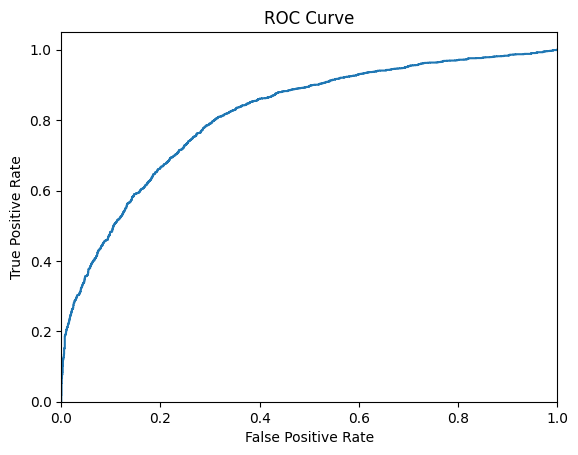

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_true, y_pred)
plt.plot(fpr, tpr)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()